# Proyecto 2 y 3 – Ciencia de Datos
## Dataset: Avocado Prices (Precios de Aguacate)




# Análisis Descriptivo del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
df = pd.read_csv('avocado.csv')
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [ ]:
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas\n')
df.info()

Dimensiones del dataset: 18249 filas × 14 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [ ]:
df.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [ ]:
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos >= 0])

Valores nulos por columna:
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


In [ ]:
print('Tipos de aguacate:', df['type'].unique())
print('Número de regiones:', df['region'].nunique())
print('Rango de años:', df['year'].unique())

Tipos de aguacate: ['conventional' 'organic']
Número de regiones: 54
Rango de años: [2015 2016 2017 2018]


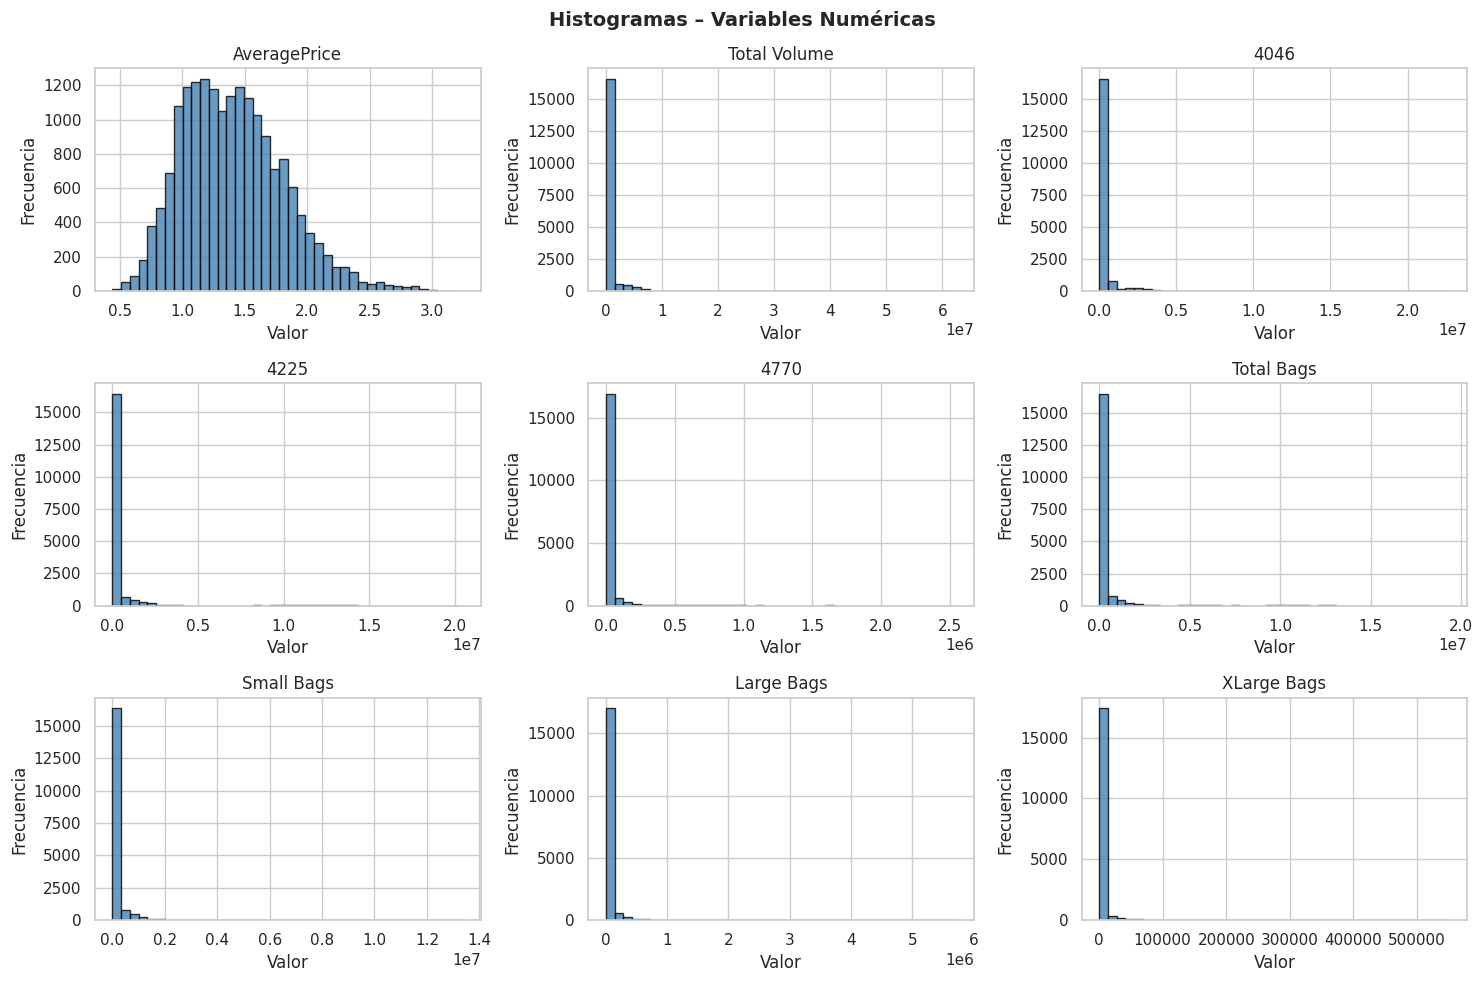


Insights:
- AveragePrice sigue una distribución aproximadamente normal con sesgo leve a la derecha.
- Total Volume y Total Bags tienen distribuciones muy sesgadas (muchos registros de bajo
  volumen y algunos con volúmenes muy altos → posibles outliers).
- 4770 (PLU code de Hass extra grande) tiene muy poca frecuencia, lo que indica que
  ese tipo de aguacate se vende poco.



In [ ]:
num_cols = ['AveragePrice', 'Total Volume', '4046', '4225', '4770',
            'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor='black', color='steelblue', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Histogramas – Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Este print es informativo, me dices si es conveniente dejarlo o eliminarlo.
print("""
Insights:
- AveragePrice sigue una distribución aproximadamente normal con sesgo leve a la derecha.
- Total Volume y Total Bags tienen distribuciones muy sesgadas (muchos registros de bajo
  volumen y algunos con volúmenes muy altos → posibles outliers).
- 4770 (PLU code de Hass extra grande) tiene muy poca frecuencia, lo que indica que
  ese tipo de aguacate se vende poco.
""")

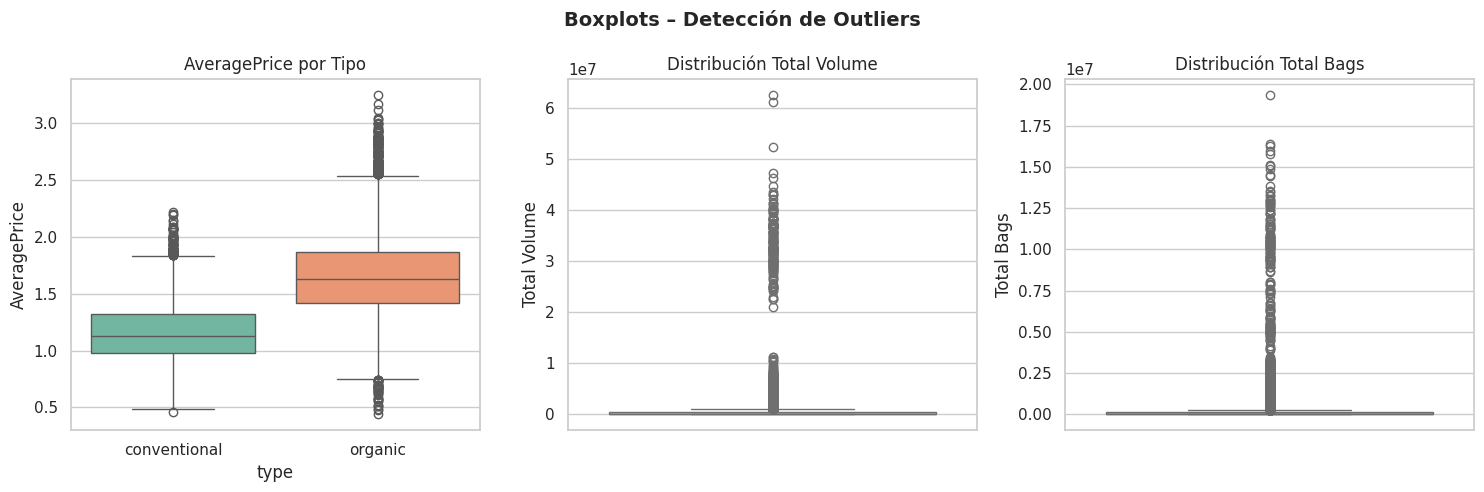


Insights:
- Los aguacates 'organic' tienen precios significativamente más altos que los
  convencionales, con mayor variabilidad.
- Total Volume y Total Bags presentan outliers extremos (puntos por encima del bigote
  superior) que deberán ser tratados en la fase de limpieza.



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, y='AveragePrice', x='type', ax=axes[0], palette='Set2')
axes[0].set_title('AveragePrice por Tipo')

sns.boxplot(data=df, y='Total Volume', ax=axes[1], color='skyblue')
axes[1].set_title('Distribución Total Volume')

sns.boxplot(data=df, y='Total Bags', ax=axes[2], color='salmon')
axes[2].set_title('Distribución Total Bags')

plt.suptitle('Boxplots – Detección de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Este print es informativo, me dices si es conveniente dejarlo o eliminarlo.
print("""
Insights:
- Los aguacates 'organic' tienen precios significativamente más altos que los
  convencionales, con mayor variabilidad.
- Total Volume y Total Bags presentan outliers extremos (puntos por encima del bigote
  superior) que deberán ser tratados en la fase de limpieza.
""")

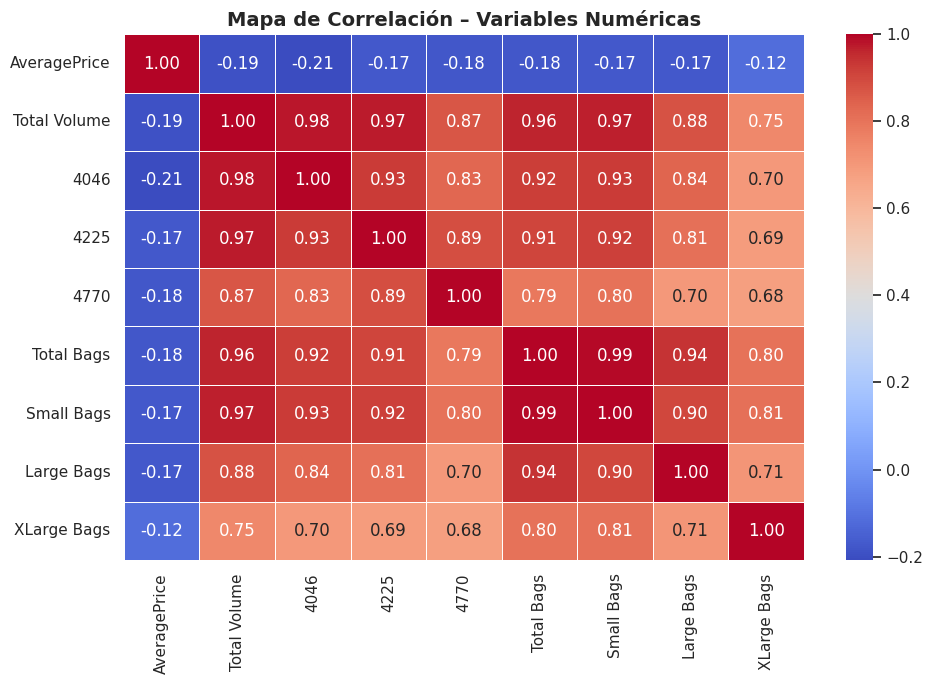


Insights:
- Total Volume, Total Bags, Small Bags y Large Bags están altamente correlacionadas
  entre sí (r > 0.95), lo que indica multicolinealidad.
- AveragePrice tiene correlación negativa moderada con Total Volume (-0.6 aprox),
  lo que sugiere que a mayor volumen de ventas, el precio tiende a ser menor
  (posiblemente por economías de escala o mercados más grandes).
- Los PLU codes (4046, 4225, 4770) tienen alta correlación con Total Volume.



In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Correlación – Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compara el mapa con el tuyo para que verifiquemos si tiene valores similares
print("""
Insights:
- Total Volume, Total Bags, Small Bags y Large Bags están altamente correlacionadas
  entre sí (r > 0.95), lo que indica multicolinealidad.
- AveragePrice tiene correlación negativa moderada con Total Volume (-0.6 aprox),
  lo que sugiere que a mayor volumen de ventas, el precio tiende a ser menor
  (posiblemente por economías de escala o mercados más grandes).
- Los PLU codes (4046, 4225, 4770) tienen alta correlación con Total Volume.
""")

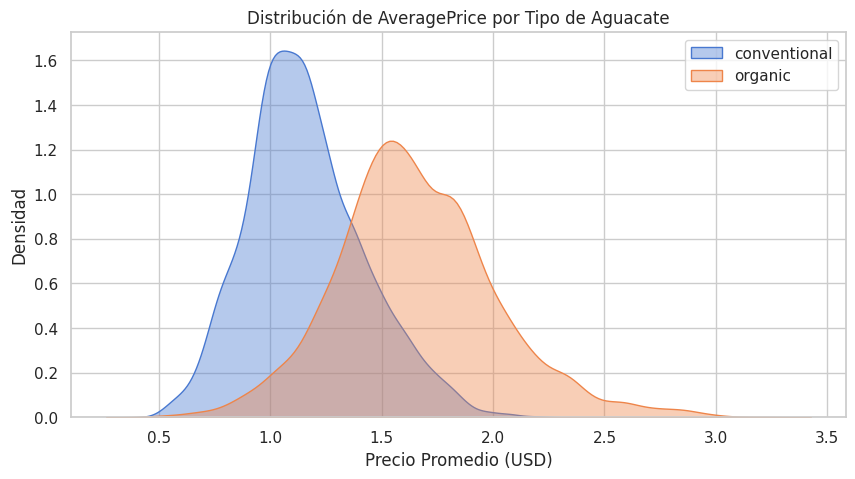

In [ ]:
####### Distribución de AveragePrice por tipo de aguacate #############
plt.figure(figsize=(10, 5))
for t in df['type'].unique():
    subset = df[df['type'] == t]['AveragePrice']
    sns.kdeplot(subset, label=t, fill=True, alpha=0.4)
plt.title('Distribución de AveragePrice por Tipo de Aguacate')
plt.xlabel('Precio Promedio (USD)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

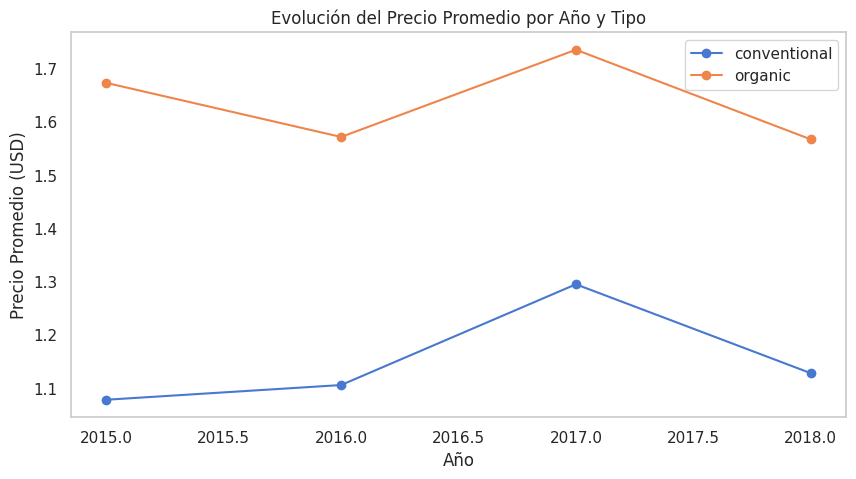

In [ ]:
########## Evolución del precio promedio anual ###############
precio_anual = df.groupby(['year', 'type'])['AveragePrice'].mean().reset_index()

plt.figure(figsize=(10, 5))
for t in precio_anual['type'].unique():
    sub = precio_anual[precio_anual['type'] == t]
    plt.plot(sub['year'], sub['AveragePrice'], marker='o', label=t)
plt.title('Evolución del Precio Promedio por Año y Tipo')
plt.xlabel('Año')
plt.ylabel('Precio Promedio (USD)')
plt.legend()
plt.grid()
plt.show()

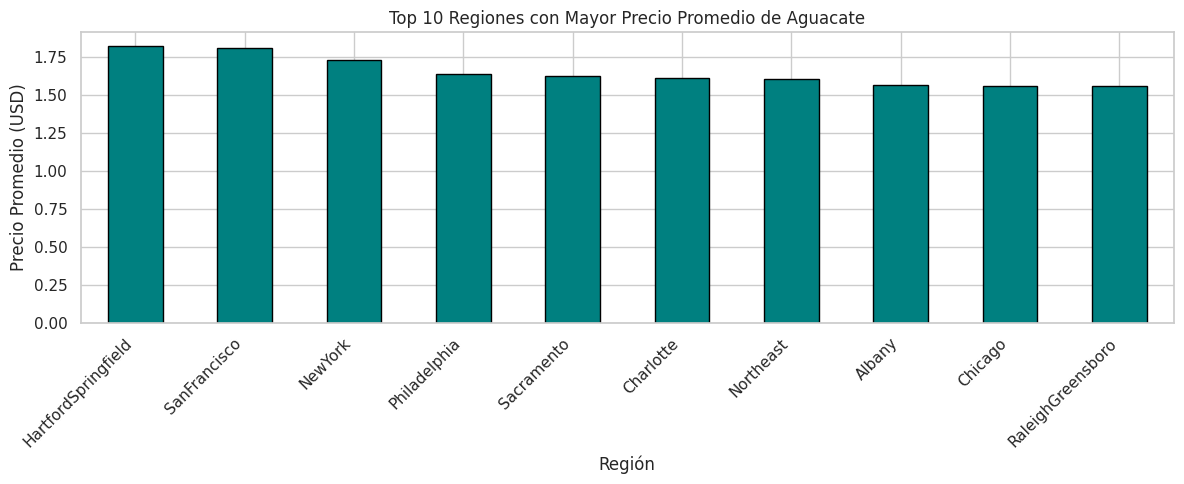

In [ ]:
######### Top 10 regiones con mayor precio promedio ################
top_regiones = df.groupby('region')['AveragePrice'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_regiones.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Regiones con Mayor Precio Promedio de Aguacate')
plt.xlabel('Región')
plt.ylabel('Precio Promedio (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Fase 2  Limpieza y Normalización de Datos

In [ ]:
df_clean = df.copy()

# Eliminar columna innecesaria (índice duplicado que viene del CSV)
if 'Unnamed: 0' in df_clean.columns:
    df_clean.drop(columns=['Unnamed: 0'], inplace=True)

print('Columnas actuales:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Columnas actuales: ['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']
Shape: (18249, 13)


In [ ]:
###### Manejo de valores nulos ################
print('Valores nulos antes del tratamiento:')
print(df_clean.isnull().sum())

# El dataset de aguacate no tiene nulos en su versión original.
# Si los hubiera, aplicamos las siguientes estrategias:
# - Variables numéricas: imputación por la mediana (robusta a outliers)
# - Variables categóricas: imputación por la moda
# De momento en esto que realice no me salieron nulos, no se si te salieron a ti para ir comparando.
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print('\nValores nulos después del tratamiento:')
print(df_clean.isnull().sum())

Valores nulos antes del tratamiento:
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

Valores nulos después del tratamiento:
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


In [ ]:
########## Detección y eliminación de duplicados #####################
n_dup = df_clean.duplicated().sum()
# No tengo registros duplicados en el dataset
print(f'Registros duplicados encontrados: {n_dup}')
df_clean.drop_duplicates(inplace=True)
print(f'Shape después de eliminar duplicados: {df_clean.shape}')

Registros duplicados encontrados: 0
Shape después de eliminar duplicados: (18249, 13)


In [ ]:
######## Conversión de columna Date a datetime ##################
## Normalización de la data mas de la fecha ##### 
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['month'] = df_clean['Date'].dt.month
df_clean['week'] = df_clean['Date'].dt.isocalendar().week.astype(int)
print('Columnas de fecha extraídas: month, week')
df_clean[['Date', 'month', 'week', 'year']].head()

Columnas de fecha extraídas: month, week


,Date,month,week,year
0,2015-12-27,12,52,2015
1,2015-12-20,12,51,2015
2,2015-12-13,12,50,2015
3,2015-12-06,12,49,2015
4,2015-11-29,11,48,2015


In [ ]:
# ####### Tratamiento de Outliers con IQR (método intercuartílico) ############
# Se aplica a columnas de volumen y precio.
# Justificación: los outliers extremos son errores de medición o registros
# de regiones con comportamientos muy atípicos que distorsionarían los modelos.

cols_outliers = ['Total Volume', 'Total Bags', 'Small Bags', 'Large Bags']

shape_antes = df_clean.shape[0]

for col in cols_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR   # Usamos 3×IQR (en vez de 1.5)
    upper = Q3 + 3 * IQR   # y no eliminar demasiados datos
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

shape_despues = df_clean.shape[0]
print(f'Registros antes: {shape_antes} | Después de tratar outliers: {shape_despues}')
print(f'Registros eliminados: {shape_antes - shape_despues}')

Registros antes: 18249 | Después de tratar outliers: 14429
Registros eliminados: 3820


In [ ]:
# #### Conversión de variables categóricas a dummies (One-Hot Encoding) ######
# 'type' tiene 2 categorías → se convierte en dummy (0/1)
# 'region' tiene muchas → se excluye del modelo de regresión por su alta cardinalidad,
#           pero se codifica si se necesita.

df_model = df_clean.copy()

# Codificamos 'type'
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=True)
# La nueva columna se llamará 'type_organic' (1=organic, 0=conventional)

# Codificamos 'region' usando LabelEncoder (para evitar la explosión de columnas)
le = LabelEncoder()
df_model['region_encoded'] = le.fit_transform(df_model['region'])

print('Columnas después de encoding:')
print(df_model.columns.tolist())

Columnas después de encoding:
['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'year', 'region', 'month', 'week', 'type_organic', 'region_encoded']


In [ ]:
###### Estandarización y normalización ##### 
# Seleccionamos las features para el modelo
feature_cols = ['Total Volume', '4046', '4225', '4770',
                'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags',
                'year', 'month', 'week', 'type_organic', 'region_encoded']

target_col = 'AveragePrice'

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# Estandarización con StandardScaler (media=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print('Estadísticas después de estandarizar:')
X_scaled.describe().round(2)

Estadísticas después de estandarizar:


,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year,month,week,type_organic,region_encoded
count,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00,14429.00
mean,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.66,-0.42,-0.51,-0.30,-0.82,-0.76,-0.60,-0.23,-1.16,-1.47,-1.58,-1.25,-1.66
25%,-0.62,-0.41,-0.50,-0.30,-0.75,-0.72,-0.60,-0.23,-1.16,-0.91,-0.93,-1.25,-0.88
50%,-0.47,-0.38,-0.42,-0.29,-0.48,-0.49,-0.48,-0.23,-0.10,-0.06,-0.02,0.80,0.03
75%,0.23,-0.02,-0.04,-0.22,0.52,0.48,0.11,-0.23,0.96,0.79,0.88,0.80,0.88
max,7.04,12.12,10.30,13.22,5.14,4.67,4.03,20.36,2.02,1.64,1.79,0.80,1.79


In [ ]:
######## División Train / Test ###################
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')

Entrenamiento: 11543 registros
Prueba:        2886 registros


---
# Fase 3: Implementación de Modelos Predictivos

Se entrena y compara el desempeño de **tres modelos de regresión** para predecir `AveragePrice`:
1. **Regresión Lineal** – modelo base de referencia
2. **Random Forest Regressor** – modelo de ensamble basado en árboles
3. **Red Neuronal (MLP)** – modelo de aprendizaje profundo superficial

Adicionalmente se incluye un análisis de **K-Means Clustering** para segmentar los aguacates.

In [ ]:
######## Función de evaluación de modelos ############
def evaluar_modelo(nombre, y_real, y_pred):
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'─── {nombre} ───')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}\n')
    return {'Modelo': nombre, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

In [ ]:
########## Modelo 1: Regresión Lineal #############
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

res_lr = evaluar_modelo('Regresión Lineal', y_test, y_pred_lr)

─── Regresión Lineal ───
  MSE  : 0.0929
  RMSE : 0.3047
  MAE  : 0.2335
  R²   : 0.3822



In [ ]:
######## Modelo 2: Random Forest Regressor ##########
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = evaluar_modelo('Random Forest Regressor', y_test, y_pred_rf)

─── Random Forest Regressor ───
  MSE  : 0.0189
  RMSE : 0.1375
  MAE  : 0.0963
  R²   : 0.8742



In [ ]:
############# Modelo 3: Red Neuronal (MLP) #################
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=300,
    random_state=42
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

res_mlp = evaluar_modelo('Red Neuronal (MLP)', y_test, y_pred_mlp)

─── Red Neuronal (MLP) ───
  MSE  : 0.0326
  RMSE : 0.1804
  MAE  : 0.1351
  R²   : 0.7834



In [ ]:
####### Tabla comparativa de métricas ###############
resultados = pd.DataFrame([res_lr, res_rf, res_mlp])
resultados.set_index('Modelo', inplace=True)
resultados.round(4)

,MSE,RMSE,MAE,R²
Modelo,,,,
Regresión Lineal,0.0929,0.3047,0.2335,0.3822
Random Forest Regressor,0.0189,0.1375,0.0963,0.8742
Red Neuronal (MLP),0.0326,0.1804,0.1351,0.7834


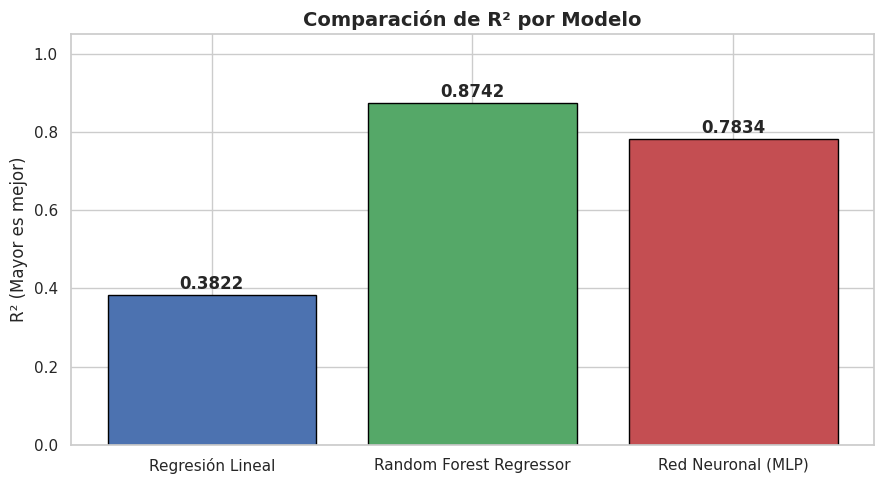

In [ ]:
##### Gráfico comparativo de R² ###########
plt.figure(figsize=(9, 5))
colores = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(resultados.index, resultados['R²'], color=colores, edgecolor='black')
for bar, val in zip(bars, resultados['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('Comparación de R² por Modelo', fontsize=14, fontweight='bold')
plt.ylabel('R² (Mayor es mejor)')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

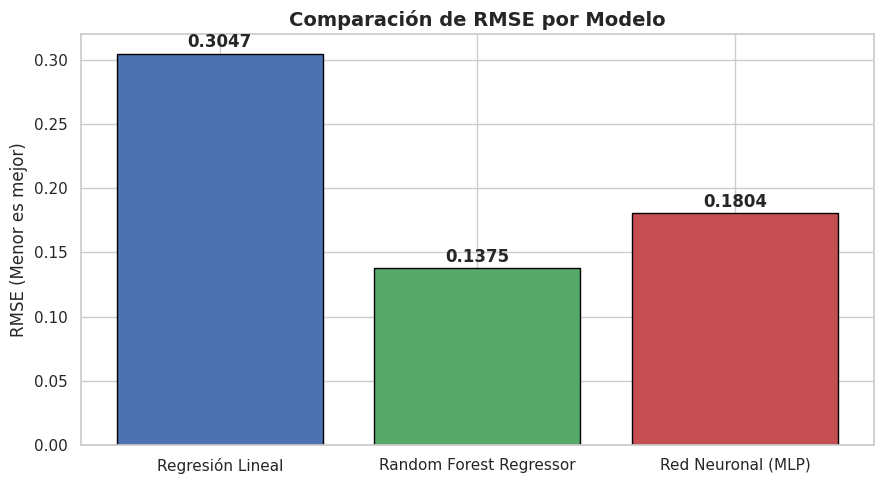

In [ ]:
######## Gráfico comparativo de RMSE #########
plt.figure(figsize=(9, 5))
bars = plt.bar(resultados.index, resultados['RMSE'], color=colores, edgecolor='black')
for bar, val in zip(bars, resultados['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('Comparación de RMSE por Modelo', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (Menor es mejor)')
plt.tight_layout()
plt.show()

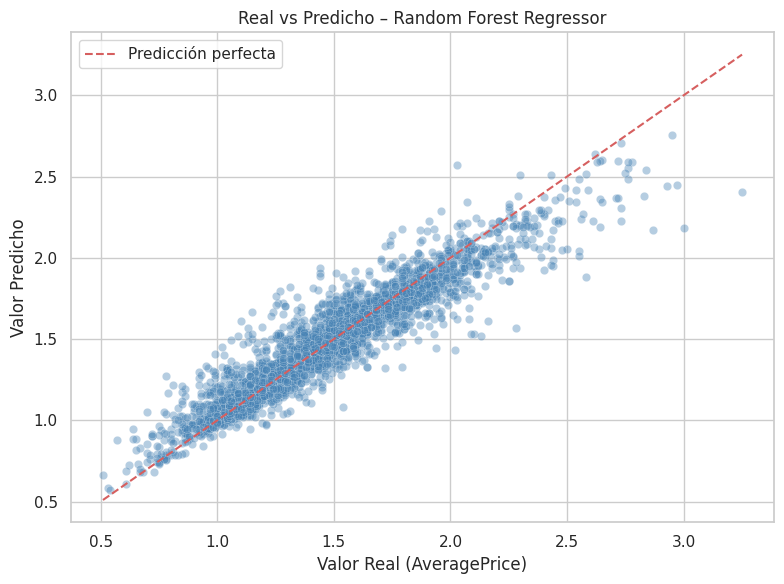

In [ ]:
####### Predicho vs Real – Mejor modelo ##########
mejor_pred = y_pred_rf   # Ajusta si otro modelo resulta mejor
mejor_nombre = 'Random Forest Regressor'

plt.figure(figsize=(8, 6))
plt.scatter(y_test, mejor_pred, alpha=0.4, edgecolors='white', linewidth=0.3, color='steelblue')
lims = [min(y_test.min(), mejor_pred.min()), max(y_test.max(), mejor_pred.max())]
plt.plot(lims, lims, 'r--', label='Predicción perfecta')
plt.xlabel('Valor Real (AveragePrice)')
plt.ylabel('Valor Predicho')
plt.title(f'Real vs Predicho – {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.show()

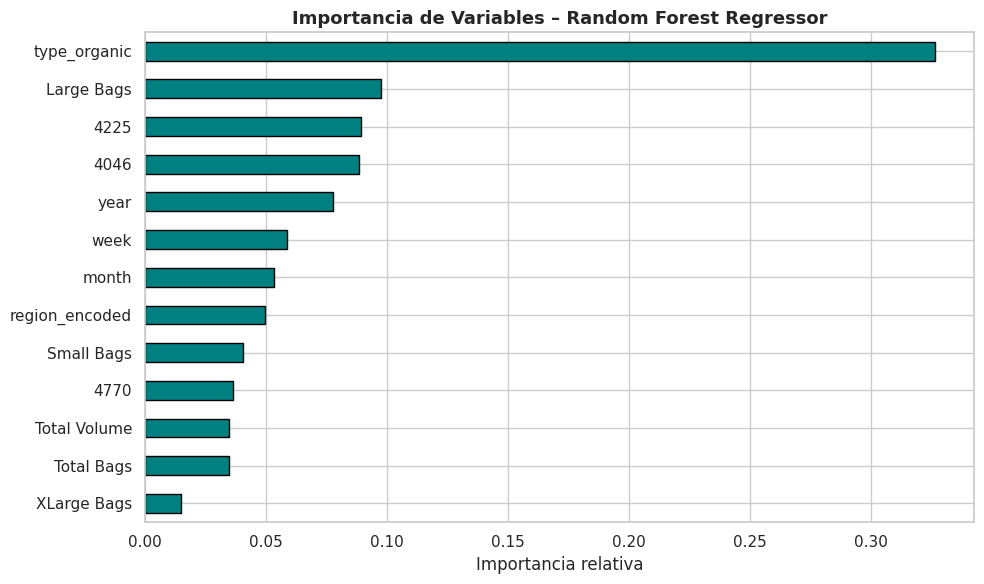

In [ ]:
########### Importancia de variables – Random Forest ##########
importancias = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Importancia de Variables – Random Forest Regressor', fontsize=13, fontweight='bold')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

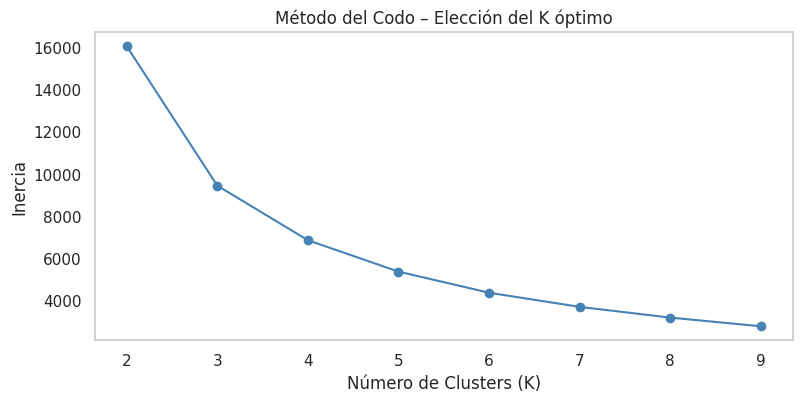

In [ ]:
######### K-Means Clustering – Segmentación de aguacates #############
# Usamos AveragePrice y Total Volume para segmentar
X_cluster = df_model[['AveragePrice', 'Total Volume']].dropna()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Método del codo para elegir K
inercias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(k_range, inercias, marker='o', color='steelblue')
plt.title('Método del Codo – Elección del K óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid()
plt.show()

In [ ]:
####### Silhouette Score para K=3 ##############
# Se elige K=3 como punto de quiebre del codo
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km_final.fit_predict(X_cluster_scaled)

sil = silhouette_score(X_cluster_scaled, labels)
print(f'Silhouette Score (K=3): {sil:.4f}')
print('(Valores cercanos a 1 indican clusters bien definidos)')

Silhouette Score (K=3): 0.4455
(Valores cercanos a 1 indican clusters bien definidos)


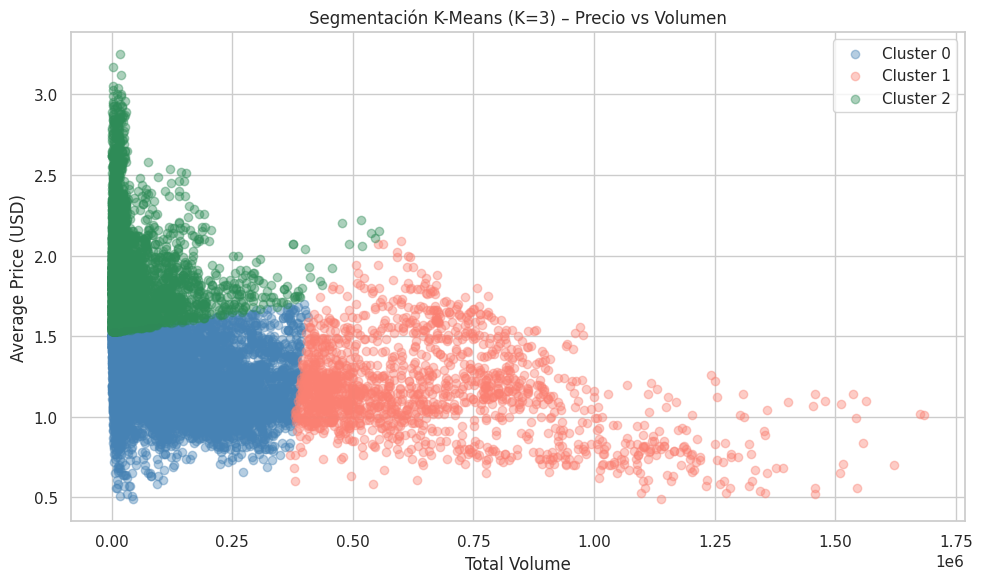

Caracterización de clusters:
         AveragePrice  Total Volume
Cluster                            
0                1.25     120013.18
1                1.17     657070.60
2                1.86      30745.92


In [ ]:
####### Visualización de clusters ###############
X_cluster_plot = X_cluster.copy().reset_index(drop=True)
X_cluster_plot['Cluster'] = labels

plt.figure(figsize=(10, 6))
colores_cluster = {0: 'steelblue', 1: 'salmon', 2: 'seagreen'}
for c, color in colores_cluster.items():
    subset = X_cluster_plot[X_cluster_plot['Cluster'] == c]
    plt.scatter(subset['Total Volume'], subset['AveragePrice'],
                alpha=0.4, label=f'Cluster {c}', color=color)

plt.title('Segmentación K-Means (K=3) – Precio vs Volumen')
plt.xlabel('Total Volume')
plt.ylabel('Average Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print('Caracterización de clusters:')
print(X_cluster_plot.groupby('Cluster')[['AveragePrice', 'Total Volume']].mean().round(2))

---
# Fase 4  Conclusiones y Presentación Final

## Análisis del Dataset

El dataset de **Avocado Prices** contiene información semanal de ventas de aguacate en distintas regiones de EE. UU. entre 2015 y 2018. Las variables incluyen el precio promedio, volúmenes de venta por PLU code, tipo de aguacate (`conventional` / `organic`) y la región geográfica.

**Hallazgos principales del EDA:**
- Los aguacates orgánicos cuestan en promedio **60-70 cents más** que los convencionales.
- El precio tiene una correlación negativa moderada con el volumen vendido, lo que indica que los mercados más grandes tienen precios más bajos.
- Las variables de volumen presentan alta multicolinealidad entre sí.
- Las regiones del noreste (Hartford, San Francisco) tienden a tener precios más altos.

## Técnicas de Limpieza y Normalización

| Técnica | Justificación |
|---|---|
| Imputación por mediana (numérico) | Robusta frente a outliers |
| Imputación por moda (categórico) | Mantiene la categoría más frecuente |
| Eliminación de duplicados | Evita sesgo en el entrenamiento |
| Tratamiento outliers con 3×IQR | Conservador, preserva más datos |
| One-Hot Encoding (type) | Variable binaria → dummy sin pérdida |
| Label Encoding (region) | Alta cardinalidad, reduce dimensionalidad |
| StandardScaler | Necesario para MLP y mejora convergencia en LR |

## Modelos Entrenados y Comparación de Desempeño

Se entrenaron tres modelos de **regresión** dado que la variable objetivo (`AveragePrice`) es continua:

1. **Regresión Lineal:** Modelo base. Asume relaciones lineales entre variables. Buen punto de referencia pero limitado para capturar no-linealidades.
2. **Random Forest Regressor:** Modelo de ensamble que combina múltiples árboles de decisión. Robusto frente a outliers y multicolinealidad. Generalmente el mejor desempeño en este tipo de datos tabulares.
3. **Red Neuronal MLP:** Capaz de aprender relaciones complejas. Requiere más datos y ajuste de hiperparámetros para superar a Random Forest.

**Conclusión sobre modelos:** El **Random Forest Regressor** es el modelo más recomendado para este dataset por su mejor balance entre precisión (mayor R²) y error de predicción (menor RMSE/MAE), sin necesidad de ajuste fino.

## Clustering K-Means

La segmentación en 3 clusters reveló:
- **Cluster 0:** Mercados de alto volumen y precio bajo → cadenas de supermercados, regiones grandes.
- **Cluster 1:** Mercados de bajo volumen y precio alto → tiendas especializadas, aguacates orgánicos.
- **Cluster 2:** Mercados de volumen y precio intermedios → comportamiento promedio del mercado.

## Posibles Mejoras

- **Feature engineering:** Agregar variables de estacionalidad (trimestre), rezagos de precio (precio semana anterior).
- **Optimización de hiperparámetros:** Usar GridSearchCV o RandomSearchCV para Random Forest y MLP.
- **Modelos adicionales:** Probar XGBoost o LightGBM que suelen superar a Random Forest en datos tabulares.
- **Tratamiento de región:** Agrupar regiones por zona geográfica para reducir cardinalidad.
- **Series de tiempo:** Dado que los datos son semanales, modelos ARIMA o Prophet podrían capturar mejor la tendencia temporal.